# H3 — LDI Across Boundary Position (Repeated Measures ANOVA)

**Design:**
- Participants are assigned to **one condition only** (between-subjects)
- Each participant contributes LDI scores for **all three boundary positions** — Pre, Mid, Post (within-subjects / repeated measures)

So we run a **one-way repeated measures ANOVA** separately for each condition:
> _Does LDI change across boundary positions (Pre → Mid → Post)?_

---
## Assumptions of Repeated Measures ANOVA

1. **Normality** — the DV should be approximately normally distributed at each level  
   → Shapiro-Wilk test + Q-Q plots per boundary position  
   → If n > 25 per group: normality can be overlooked (CLT)  
   → If violated with small n: use **Friedman test** (non-parametric alternative)

2. **Sphericity** — the variances of the *differences* between all pairs of levels must be equal  
   → Mauchly's test  
   → If violated: apply **Greenhouse-Geisser correction** (adjusts degrees of freedom)  
   → Note: with only 3 levels, Greenhouse-Geisser correction is commonly applied as a precaution

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import shapiro, probplot, spearmanr
import pingouin as pg

sns.set(style='whitegrid', context='talk')

data_path = Path('..') / '01_Preprocessing' / 'compiled_preprocessed.csv'
df = pd.read_csv(data_path)
df['boundary_position'] = pd.Categorical(
    df['boundary_position'], categories=['Pre', 'Mid', 'Post'], ordered=True
)

## Step 1 — Build LDI (wide format per condition)

Each row = one participant. Columns: LDI_Pre, LDI_Mid, LDI_Post.

In [2]:
def p_resp(data, trial_type, response, boundary=None):
    x = data[data['trial_type'] == trial_type]
    if boundary is not None:
        x = x[x['boundary_position'] == boundary]
    if x.empty:
        return np.nan
    return (x['user_response'] == response).mean()

rows = []
for (pid, cond), sub in df.groupby(['participant_id', 'condition']):
    foil_sim = p_resp(sub, 'Foil', 'Lure')
    rows.append({
        'participant_id': pid,
        'condition': cond,
        'LDI_Pre':  p_resp(sub, 'Lure', 'Lure', 'Pre')  - foil_sim,
        'LDI_Mid':  p_resp(sub, 'Lure', 'Lure', 'Mid')  - foil_sim,
        'LDI_Post': p_resp(sub, 'Lure', 'Lure', 'Post') - foil_sim,
    })

wide_df = pd.DataFrame(rows).dropna()
conditions = sorted(wide_df['condition'].unique())

print('Total participants (complete cases):', len(wide_df))
print('\nParticipants per condition:')
display(wide_df.groupby('condition').size().rename('n'))

print('\nMean LDI per condition × position:')
display(
    wide_df.groupby('condition')[['LDI_Pre','LDI_Mid','LDI_Post']]
    .mean().round(4)
)

Total participants (complete cases): 160

Participants per condition:


condition
Both_item_task    51
item_only         56
task_only         53
Name: n, dtype: int64


Mean LDI per condition × position:


,LDI_Pre,LDI_Mid,LDI_Post
condition,,,
Both_item_task,0.2667,0.2892,0.2549
item_only,0.3128,0.3364,0.3190
task_only,0.3972,0.3684,0.3930


---
## Assumption 1 — Normality

Check normality of LDI **at each boundary position** within each condition.

- **Shapiro-Wilk p > .05** → cannot reject normality → assumption holds
- **Q-Q plot points on diagonal** → visually normal
- **Spearman r on Q-Q points ≈ 1.0** → strong linear alignment with normal distribution
- If **n > 25** in every group → CLT applies and normality is not a concern

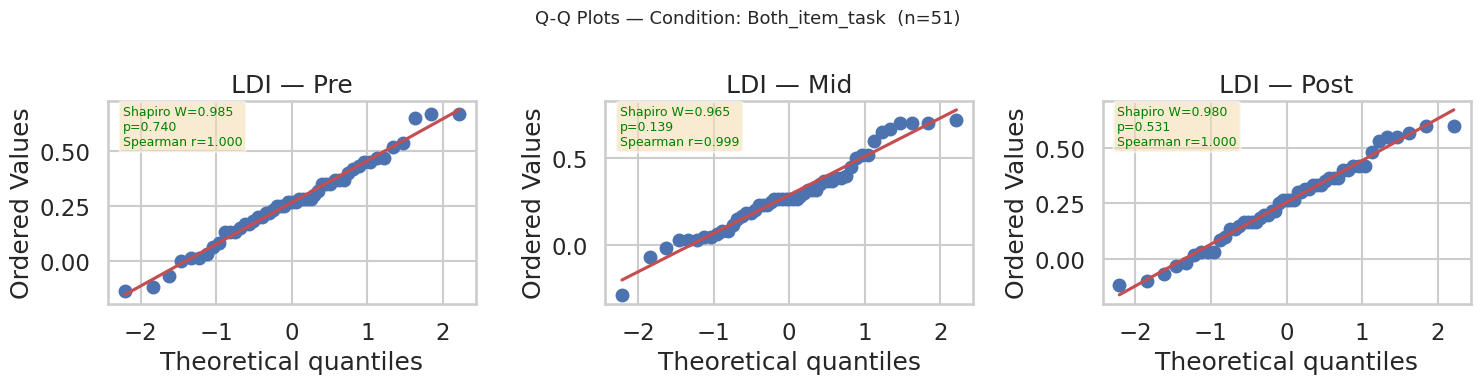

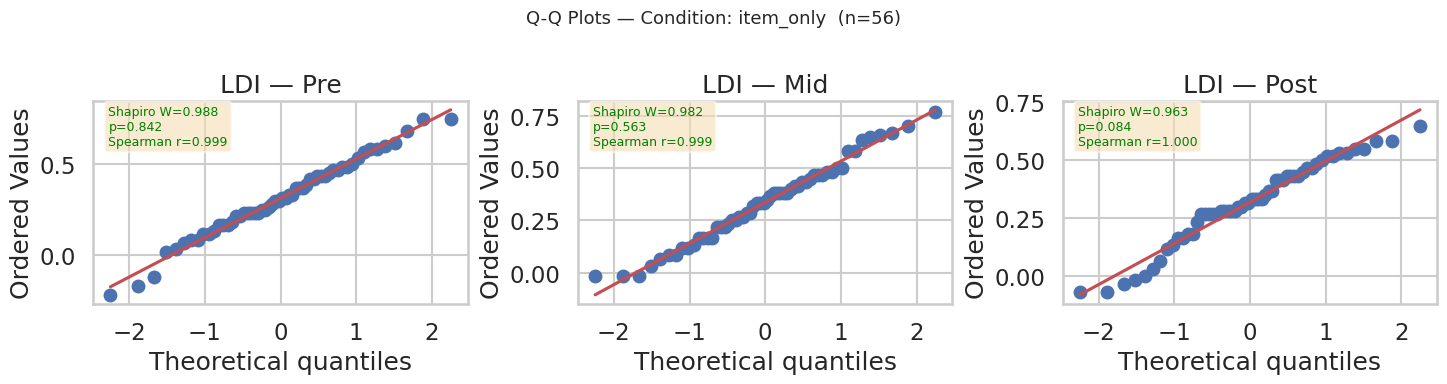

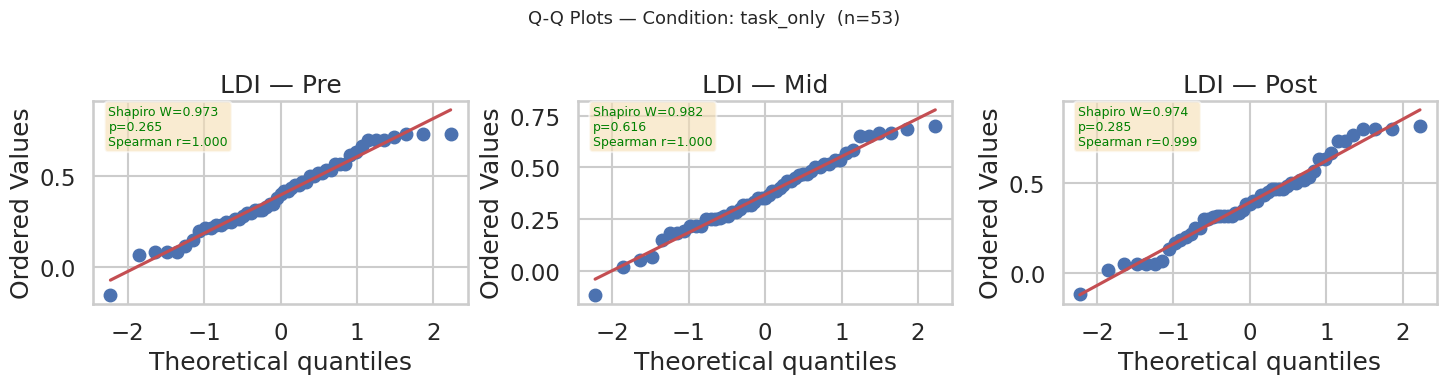


Normality Summary:


,condition,position,n,shapiro_W,shapiro_p,normal (p>.05),n>25 (CLT),QQ_spearman_r
0,Both_item_task,Pre,51,0.9845,0.7401,True,True,0.9996
1,Both_item_task,Mid,51,0.9652,0.1392,True,True,0.9992
2,Both_item_task,Post,51,0.9798,0.5315,True,True,0.9997
3,item_only,Pre,56,0.9878,0.8419,True,True,0.9994
4,item_only,Mid,56,0.9819,0.5630,True,True,0.9994
5,item_only,Post,56,0.9631,0.0841,True,True,0.9996
6,task_only,Pre,53,0.9728,0.2647,True,True,0.9997
7,task_only,Mid,53,0.9823,0.6160,True,True,0.9997
8,task_only,Post,53,0.9735,0.2846,True,True,0.9993


In [3]:
positions = ['Pre', 'Mid', 'Post']
normality_results = []

for cond in conditions:
    cond_data = wide_df[wide_df['condition'] == cond]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'Q-Q Plots — Condition: {cond}  (n={len(cond_data)})', fontsize=13)

    for ax, pos in zip(axes, positions):
        vals = cond_data[f'LDI_{pos}'].dropna()

        (osm, osr), _ = probplot(vals, dist='norm', plot=ax)
        ax.set_title(f'LDI — {pos}')

        sw_stat, sw_p   = shapiro(vals)
        spear_r, spear_p = spearmanr(osm, osr)

        normality_results.append({
            'condition': cond,
            'position': pos,
            'n': len(vals),
            'shapiro_W': round(sw_stat, 4),
            'shapiro_p': round(sw_p, 4),
            'normal (p>.05)': sw_p > 0.05,
            'n>25 (CLT)': len(vals) > 25,
            'QQ_spearman_r': round(spear_r, 4),
        })

        color = 'green' if sw_p > 0.05 else 'red'
        ax.annotate(
            f'Shapiro W={sw_stat:.3f}\np={sw_p:.3f}\nSpearman r={spear_r:.3f}',
            xy=(0.04, 0.78), xycoords='axes fraction', fontsize=9,
            color=color,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.6)
        )

    plt.tight_layout()
    plt.show()

norm_df = pd.DataFrame(normality_results)
print('\nNormality Summary:')
display(norm_df)

---
## Assumption 2 — Sphericity (Mauchly's Test)

Sphericity is the repeated-measures equivalent of homogeneity of variance.  
It requires that the **variance of the differences** between every pair of levels (Pre–Mid, Mid–Post, Pre–Post) are equal.

- **Mauchly's W ≈ 1, p > .05** → Sphericity holds → standard RM-ANOVA F-statistic is valid
- **p < .05** → Sphericity violated → apply **Greenhouse-Geisser (GG) correction** to the degrees of freedom

> With only 3 levels (k=3) there is just one sphericity constraint, so Mauchly's test has limited power.  
> It is common practice to always report GG-corrected results as a precaution.

In [4]:
sphericity_results = []

for cond in conditions:
    cond_data = wide_df[wide_df['condition'] == cond].copy()
    cols = cond_data[['LDI_Pre', 'LDI_Mid', 'LDI_Post']]

    # pg.sphericity returns 5 values: (spher, W, chi2, dof, pval)
    spher, W, chi2, dof, p_val = pg.sphericity(cols)

    # Greenhouse-Geisser epsilon (how far from sphericity; 1.0 = perfect)
    gg = pg.epsilon(cols, correction='gg')

    sphericity_results.append({
        'condition': cond,
        'Mauchly_W': round(W, 4),
        'chi2': round(chi2, 4),
        'df': dof,
        'p_value': round(p_val, 4),
        'sphericity_holds (p>.05)': p_val > 0.05,
        'GG_epsilon': round(gg, 4),
        'GG_correction_needed': p_val < 0.05,
    })

sph_df = pd.DataFrame(sphericity_results)
print("Mauchly's Sphericity Test:")
display(sph_df)

print("\nGG epsilon interpretation:")
print("  ε = 1.0  → perfect sphericity")
print("  ε < 0.75 → strong violation, GG correction essential")
print("  ε > 0.75 → mild violation, Huynh-Feldt correction also acceptable")

Mauchly's Sphericity Test:


,condition,Mauchly_W,chi2,df,p_value,sphericity_holds (p>.05),GG_epsilon,GG_correction_needed
0,Both_item_task,0.9950,0.2451,2,0.8847,True,0.9950,False
1,item_only,0.9611,2.1405,2,0.3429,True,0.9626,False
2,task_only,0.9613,2.0121,2,0.3657,True,0.9628,False



GG epsilon interpretation:
  ε = 1.0  → perfect sphericity
  ε < 0.75 → strong violation, GG correction essential
  ε > 0.75 → mild violation, Huynh-Feldt correction also acceptable


The assumptions of ANOVA are satisfied and hence we proceeed to conduct the RM ANOVA

In [5]:
summary_rows = []

for cond in conditions:
    # --- normality decision ---
    cond_norm   = norm_df[norm_df['condition'] == cond]
    all_normal  = cond_norm['normal (p>.05)'].all()
    all_clt     = cond_norm['n>25 (CLT)'].all()
    normality_ok = all_normal or all_clt
    normality_note = (
        'Yes — Shapiro p>.05' if all_normal
        else 'Yes — n>25, CLT applies' if all_clt
        else 'NO — violated'
    )

    # --- sphericity decision ---
    sph_row  = sph_df[sph_df['condition'] == cond].iloc[0]
    sph_ok   = sph_row['sphericity_holds (p>.05)']
    sph_note = (
        f"Yes — Mauchly p={sph_row['p_value']}" if sph_ok
        else f"NO — violated (ε={sph_row['GG_epsilon']})"
    )

    # --- recommended test ---
    if not normality_ok:
        test = 'Friedman test (non-parametric)'
    elif sph_ok:
        test = 'RM-ANOVA (standard)'
    else:
        test = 'RM-ANOVA + Greenhouse-Geisser correction'

    summary_rows.append({
        'Condition': cond,
        'Normality': normality_note,
        'Sphericity': sph_note,
        'Recommended Test': test,
    })

summary_df = pd.DataFrame(summary_rows)
print('=== Repeated Measures ANOVA — Assumption Check Summary ===')
display(summary_df)

=== Repeated Measures ANOVA — Assumption Check Summary ===


,Condition,Normality,Sphericity,Recommended Test
0,Both_item_task,Yes — Shapiro p>.05,Yes — Mauchly p=0.8847,RM-ANOVA (standard)
1,item_only,Yes — Shapiro p>.05,Yes — Mauchly p=0.3429,RM-ANOVA (standard)
2,task_only,Yes — Shapiro p>.05,Yes — Mauchly p=0.3657,RM-ANOVA (standard)


---
## Step 3 — One-Way Repeated Measures ANOVA (per condition)

Both assumptions are satisfied (normality + sphericity) → proceed with standard RM-ANOVA.

**What it tests:** Is there a statistically significant difference in mean LDI across the three boundary positions (Pre, Mid, Post) within each condition?

- **F-statistic** — ratio of variance explained by position vs. residual variance
- **p < .05** → at least one position mean is significantly different from another
- **η² (eta-squared)** — effect size: proportion of variance explained by position  
  - η² < 0.06 → small | 0.06–0.14 → medium | > 0.14 → large

> RM-ANOVA tells us **IF** there is a difference. Post-hoc tests (next cell) tell us **WHERE**.

In [6]:
# pingouin needs long format: participant_id | boundary_position | LDI
long_df = wide_df.melt(
    id_vars=['participant_id', 'condition'],
    value_vars=['LDI_Pre', 'LDI_Mid', 'LDI_Post'],
    var_name='boundary_position',
    value_name='LDI'
)

In [7]:
long_df[(long_df['condition'] == 'item_only') & (long_df['participant_id'] == 1)]

,participant_id,condition,boundary_position,LDI
0,1,item_only,LDI_Pre,0.233333
160,1,item_only,LDI_Mid,0.383333
320,1,item_only,LDI_Post,0.283333


In [8]:
long_df['boundary_position'] = long_df['boundary_position'].str.replace('LDI_', '')
long_df['boundary_position'] = pd.Categorical(
    long_df['boundary_position'], categories=['Pre', 'Mid', 'Post'], ordered=True
)
long_df.head()

,participant_id,condition,boundary_position,LDI
0,1,item_only,Pre,0.233333
1,2,item_only,Pre,0.433333
2,3,item_only,Pre,-0.116667
3,4,item_only,Pre,0.250000
4,5,item_only,Pre,0.133333


In [9]:
for cond in conditions:
    cond_long = long_df[long_df['condition'] == cond]
    print(cond_long)

     participant_id       condition boundary_position       LDI
14               15  Both_item_task               Pre  0.133333
16               16  Both_item_task               Pre  0.400000
18               17  Both_item_task               Pre  0.283333
20               18  Both_item_task               Pre -0.133333
22               19  Both_item_task               Pre  0.200000
..              ...             ...               ...       ...
465              63  Both_item_task              Post  0.366667
467              64  Both_item_task              Post  0.416667
469              65  Both_item_task              Post  0.333333
471              66  Both_item_task              Post  0.600000
473              67  Both_item_task              Post  0.150000

[153 rows x 4 columns]
     participant_id  condition boundary_position       LDI
0                 1  item_only               Pre  0.233333
1                 2  item_only               Pre  0.433333
2                 3  item_only 

In [10]:
anova_results = []

for cond in conditions:
    cond_long = long_df[long_df['condition'] == cond]

    # pg.rm_anova returns one row per within-factor
    # Columns: Source, ddof1, ddof2, F, p_unc, ng2, eps
    aov = pg.rm_anova(
        data=cond_long,
        dv='LDI',
        within='boundary_position',
        subject='participant_id',
    )

    row  = aov.iloc[0]
    eta2 = row['ng2']    # generalized eta-squared
    p    = row['p_unc']

    anova_results.append({
        'condition':          cond,
        'F':                  round(row['F'], 4),
        'df_num':             int(row['ddof1']),
        'df_den':             int(row['ddof2']),
        'p_value':            round(p, 4),
        'significant (p<.05)': p < 0.05,
        'η²g':                round(eta2, 4),
        'effect size': (
            'large'  if eta2 > 0.14 else
            'medium' if eta2 > 0.06 else
            'small'
        )
    })

anova_df = pd.DataFrame(anova_results)
print('One-Way Repeated Measures ANOVA — LDI ~ boundary_position (per condition)')
display(anova_df)

One-Way Repeated Measures ANOVA — LDI ~ boundary_position (per condition)


,condition,F,df_num,df_den,p_value,significant (p<.05),η²g,effect size
0,Both_item_task,1.2549,2,100,0.2895,False,0.0053,small
1,item_only,0.7351,2,110,0.4818,False,0.0027,small
2,task_only,1.1788,2,104,0.3117,False,0.0039,small


Participants' ability to discriminate lures from targets (LDI) does not depend on where the item appeared relative to the event boundary — Pre, Mid, and Post boundary items are equally well (or poorly) discriminated. The event boundary position does not modulate pattern separation in this dataset.

---
# Mixed ANOVA — LDI ~ Condition × Boundary Position

The RM-ANOVA tested each condition separately. Now we combine both factors simultaneously:

| Factor | Type | Levels |
|---|---|---|
| **condition** | Between-subjects | Both_item_task, item_only, task_only |
| **boundary_position** | Within-subjects (repeated measures) | Pre, Mid, Post |

Three effects to test:
1. **Main effect of condition** — does overall LDI level differ between conditions?
2. **Main effect of boundary_position** — does LDI differ across positions (collapsed across conditions)?
3. **Interaction** — does the pattern of LDI across positions *differ depending on condition*?

---
## Additional Assumption — Homogeneity of Variance Across Conditions (Levene's Test)

For the between-subjects factor, at **each level of boundary_position**, the variance in LDI must be equal across conditions.
- **p > .05** → equal variances → assumption holds

In [11]:
from scipy.stats import levene

levene_results = []
for pos in positions:
    groups = [
        wide_df[wide_df['condition'] == cond][f'LDI_{pos}'].dropna().values
        for cond in conditions
    ]
    stat, p = levene(*groups)
    variances = [g.var(ddof=1) for g in groups]
    levene_results.append({
        'boundary_position': pos,
        **{f'var_{c}': round(v, 5) for c, v in zip(conditions, variances)},
        'levene_stat': round(stat, 4),
        'levene_p': round(p, 4),
        'equal variances (p>.05)': p > 0.05,
    })

levene_df = pd.DataFrame(levene_results)
print("Levene's Test — Homogeneity of Variance Across Conditions (per position):")
display(levene_df)

Levene's Test — Homogeneity of Variance Across Conditions (per position):


,boundary_position,var_Both_item_task,var_item_only,var_task_only,levene_stat,levene_p,equal variances (p>.05)
0,Pre,0.03447,0.04492,0.04273,0.8541,0.4276,True
1,Mid,0.04776,0.03727,0.03265,0.3117,0.7327,True
2,Post,0.03409,0.03094,0.05174,1.8268,0.1643,True


---
## Mixed ANOVA — Results

`pg.mixed_anova` columns: `Source, SS, DF1, DF2, MS, F, p_unc, np2, eps`
- **np2** = partial η² (effect size)  
  - < 0.06 → small | 0.06–0.14 → medium | > 0.14 → large

> **Important:** Since participant IDs overlap across conditions (between-subjects design), we create a unique identifier `uid = condition + participant_id` to satisfy pingouin's requirement.

In [12]:
# unique subject ID per condition (required by pingouin when IDs overlap across groups)
long_df['uid'] = long_df['condition'].astype(str) + '_' + long_df['participant_id'].astype(str)

mixed = pg.mixed_anova(
    data=long_df,
    dv='LDI',
    within='boundary_position',
    between='condition',
    subject='uid',
)

# tidy up for display
mixed_display = mixed[['Source', 'DF1', 'DF2', 'F', 'p_unc', 'np2']].copy()
mixed_display.columns = ['Source', 'df_num', 'df_den', 'F', 'p_value', 'partial η²']
mixed_display['F']         = mixed_display['F'].round(4)
mixed_display['p_value']   = mixed_display['p_value'].round(4)
mixed_display['partial η²'] = mixed_display['partial η²'].round(4)
mixed_display['significant (p<.05)'] = mixed_display['p_value'] < 0.05
mixed_display['effect size'] = mixed_display['partial η²'].apply(
    lambda x: 'large' if x > 0.14 else ('medium' if x > 0.06 else 'small')
)

print('Mixed ANOVA — LDI ~ condition (between) × boundary_position (within)')
display(mixed_display)

Mixed ANOVA — LDI ~ condition (between) × boundary_position (within)


,Source,df_num,df_den,F,p_value,partial η²,significant (p<.05),effect size
0,condition,2,157,5.4980,0.0049,0.0655,True,medium
1,boundary_position,2,314,0.2836,0.7532,0.0018,False,small
2,Interaction,4,314,1.4494,0.2176,0.0181,False,small


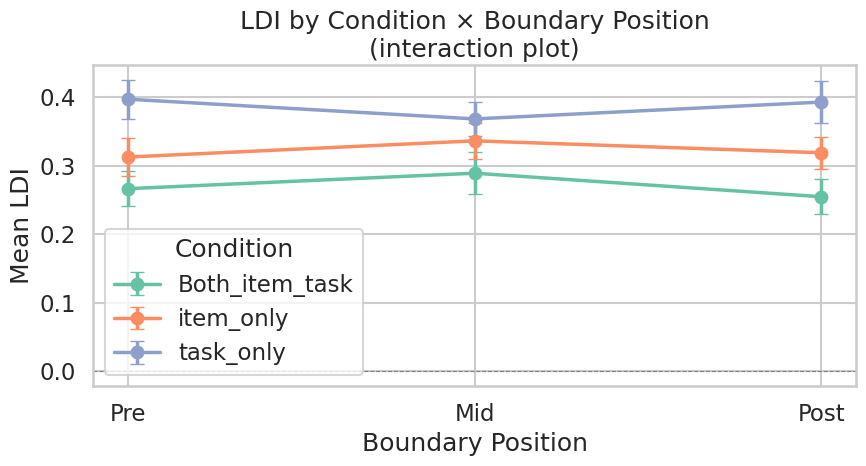

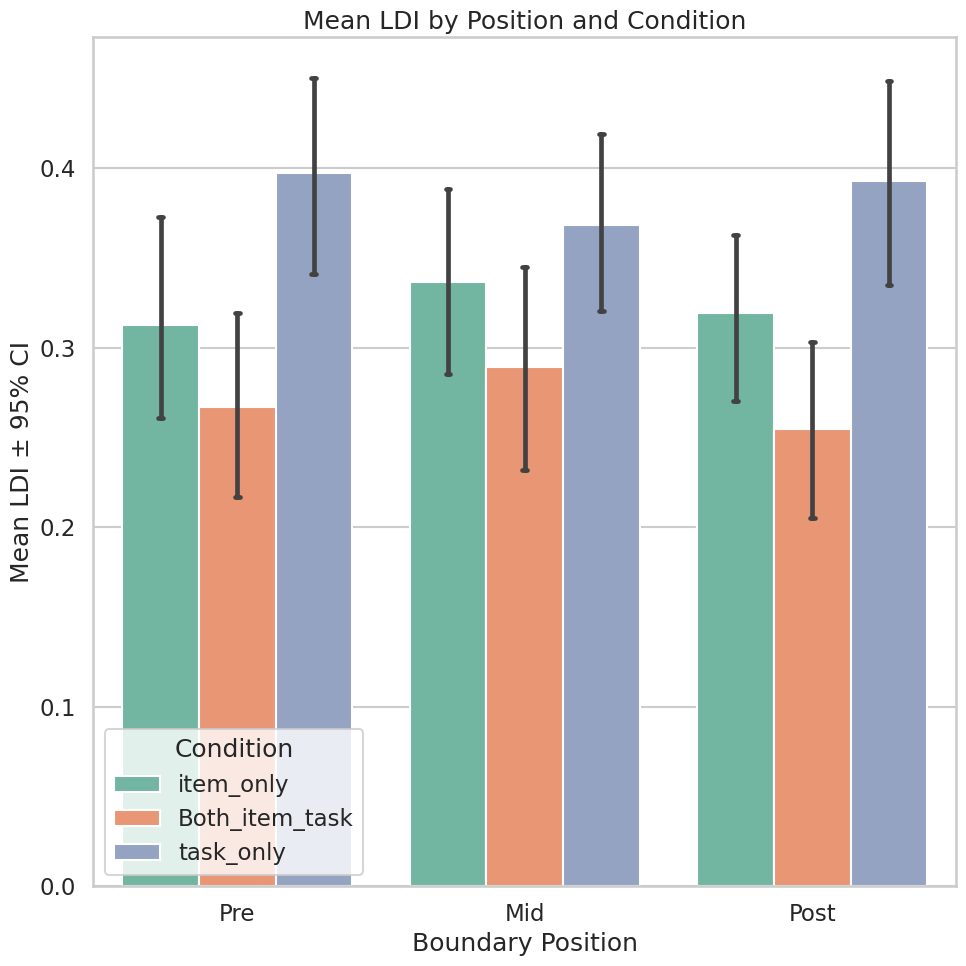

In [21]:
pos_order = ['Pre', 'Mid', 'Post']
palette   = sns.color_palette('Set2', len(conditions))

# ── Interaction plot: Mean LDI per condition × position ───────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
for color, cond in zip(palette, conditions):
    means = [wide_df[wide_df['condition'] == cond][f'LDI_{p}'].mean() for p in pos_order]
    sems  = [wide_df[wide_df['condition'] == cond][f'LDI_{p}'].sem()  for p in pos_order]
    ax.errorbar(pos_order, means, yerr=sems, label=cond,
                marker='o', linewidth=2.5, markersize=9, capsize=5, color=color)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Boundary Position')
ax.set_ylabel('Mean LDI')
ax.set_title('LDI by Condition × Boundary Position\n(interaction plot)')
ax.legend(title='Condition')
plt.tight_layout()
plt.show()

# ── Grouped bar chart ─────────────────────────────────────────────────────────
plot_long = wide_df.melt(
    id_vars=['condition'],
    value_vars=['LDI_Pre', 'LDI_Mid', 'LDI_Post'],
    var_name='position', value_name='LDI'
)
plot_long['position'] = plot_long['position'].str.replace('LDI_', '')
plot_long['position'] = pd.Categorical(plot_long['position'], categories=pos_order, ordered=True)

fig, ax = plt.subplots(figsize=(10, 10))
sns.barplot(data=plot_long, x='position', y='LDI', hue='condition',
            palette='Set2', order=pos_order, ax=ax, capsize=0.05)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Boundary Position')
ax.set_ylabel('Mean LDI ± 95% CI')
ax.set_title('Mean LDI by Position and Condition')
ax.legend(title='Condition')
plt.tight_layout()
plt.show()

---
## Conclusions — Mixed ANOVA

| Effect | Result | Interpretation |
|---|---|---|
| **condition** (between) | F(2,157)=5.50, p=0.005, η²=0.065 | **Significant, medium effect** — LDI differs across conditions |
| **boundary_position** (within) | F(2,314)=0.28, p=0.753, η²=0.002 | Not significant — LDI does not change across Pre/Mid/Post |
| **Interaction** | F(4,314)=1.45, p=0.218, η²=0.018 | Not significant — all conditions show the same flat pattern across positions |

### Key takeaways
- Since the **interaction is NOT significant**, the lines across positions are roughly parallel across conditions — the conditions shift the *level* of LDI but not the *shape* of how it changes across positions
- Since **boundary_position is NOT significant**, we can confirm (again) that where an item appears relative to an event boundary does not affect lure discrimination
- Since **condition IS significant**, there is a genuine between-group difference in overall LDI — we need post-hoc tests to find **which pairs of conditions differ**

### Post-hoc strategy
- Only the **condition** main effect needs post-hoc testing (boundary_position and interaction are not significant)
- Compare all pairs of conditions on their **mean LDI** (averaged across positions) using **Tukey's HSD** — the standard post-hoc for between-subjects pairwise comparisons after a significant ANOVA

---
## Post-Hoc Tests — Condition Main Effect (Tukey's HSD)

Since condition is between-subjects, we average LDI across all three positions per participant and run **Tukey's HSD** on those mean LDI scores.

Tukey's HSD tests all pairwise comparisons while controlling the familywise error rate — appropriate when comparing 3 groups after a significant ANOVA.

In [14]:
# mean LDI per participant across all positions (the between-subjects DV)
wide_df['LDI_mean'] = wide_df[['LDI_Pre', 'LDI_Mid', 'LDI_Post']].mean(axis=1)

print('Mean LDI per condition (averaged across positions):')
display(wide_df.groupby('condition')['LDI_mean'].agg(['mean', 'std', 'count']).round(4))

# Tukey's HSD — columns: A, B, mean_A, mean_B, diff, se, T, p_tukey, hedges
tukey = pg.pairwise_tukey(data=wide_df, dv='LDI_mean', between='condition')
tukey = tukey[['A', 'B', 'mean_A', 'mean_B', 'diff', 'se', 'T', 'p_tukey', 'hedges']].copy()
tukey.columns = ['Cond A', 'Cond B', 'mean A', 'mean B', 'diff (A-B)', 'SE', 't', 'p_tukey', "Hedges' g"]
tukey['p_tukey']         = tukey['p_tukey'].round(4)
tukey["Hedges' g"]       = tukey["Hedges' g"].round(4)
tukey['diff (A-B)']      = tukey['diff (A-B)'].round(4)
tukey['significant (p<.05)'] = tukey['p_tukey'] < 0.05

print('\nTukey HSD Post-Hoc — Pairwise Condition Comparisons:')
display(tukey)

Mean LDI per condition (averaged across positions):


,mean,std,count
condition,,,
Both_item_task,0.2703,0.1747,51
item_only,0.3228,0.1735,56
task_only,0.3862,0.1874,53



Tukey HSD Post-Hoc — Pairwise Condition Comparisons:


,Cond A,Cond B,mean A,mean B,diff (A-B),SE,t,p_tukey,Hedges' g,significant (p<.05)
0,Both_item_task,item_only,0.270261,0.322759,-0.0525,0.034573,-1.518470,0.2850,-0.2994,False
1,Both_item_task,task_only,0.270261,0.386181,-0.1159,0.035036,-3.308583,0.0033,-0.6346,True
2,item_only,task_only,0.322759,0.386181,-0.0634,0.034230,-1.852835,0.1561,-0.3491,False


/tmp/ipykernel_62750/785176386.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=wide_df, x='condition', y='LDI_mean', order=cond_order,


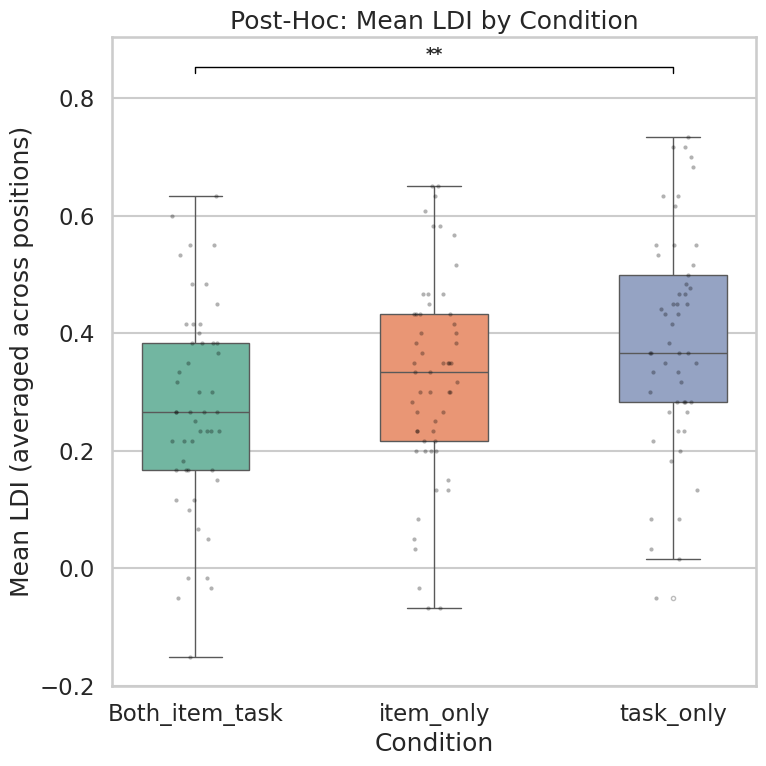

In [18]:
def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

fig, ax = plt.subplots(figsize=(8, 8))
cond_order = sorted(wide_df['condition'].unique())
sns.boxplot(data=wide_df, x='condition', y='LDI_mean', order=cond_order,
            palette='Set2', width=0.45, ax=ax,
            flierprops=dict(marker='o', markersize=3, alpha=0.4))
sns.stripplot(data=wide_df, x='condition', y='LDI_mean', order=cond_order,
              color='black', alpha=0.3, size=3, jitter=True, ax=ax)

# annotate significant Tukey pairs with brackets
y_max = wide_df['LDI_mean'].max()
step  = 0.06
for i, row in tukey.iterrows():
    if row['significant (p<.05)']:
        x1 = cond_order.index(row['Cond A'])
        x2 = cond_order.index(row['Cond B'])
        y  = y_max + step * (i + 1)
        ax.plot([x1, x1, x2, x2], [y - 0.01, y, y, y - 0.01], color='black', linewidth=1)
        ax.text((x1 + x2) / 2, y + 0.005, sig_stars(row['p_tukey']),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Condition')
ax.set_ylabel('Mean LDI (averaged across positions)')
ax.set_title('Post-Hoc: Mean LDI by Condition')
plt.tight_layout()
plt.show()

---
## Understanding Hedges' g (Effect Size)

**Hedges' g** measures *how large* the difference between two groups is, expressed in standard deviation units.

> g = (mean of group A − mean of group B) / pooled standard deviation

It answers the question the p-value cannot: **"Even if the difference is real, does it actually matter?"**

| Hedges' g (absolute value) | Interpretation |
|---|---|
| 0.0 – 0.2 | Negligible |
| 0.2 – 0.5 | Small |
| 0.5 – 0.8 | Medium |
| > 0.8 | Large |

> **Sign:** A negative g means Group B has a *higher* mean than Group A (since diff = mean_A − mean_B).

---
## Conclusions from Tukey HSD Post-Hoc

| Pair | p_tukey | Hedges' g | Significant? | Interpretation |
|---|---|---|---|---|
| Both_item_task vs item_only | 0.285 | −0.30 (small) | No | No meaningful difference in LDI between these two conditions |
| Both_item_task vs task_only | **0.003** | **−0.63 (medium-large)** | **Yes** | `task_only` has significantly higher LDI than `Both_item_task` |
| item_only vs task_only | 0.156 | −0.35 (small) | No | Trend toward task_only being higher, but not significant |

### Key finding
The significant condition effect in the Mixed ANOVA is driven entirely by the **Both_item_task vs task_only** contrast.

**Participants in the `task_only` condition showed meaningfully better lure discrimination (higher LDI) than those in the `Both_item_task` condition** (g = −0.63, p = 0.003).

**Possible explanation:** When participants must encode *both* item identity and source information simultaneously (`Both_item_task`), cognitive load may reduce pattern separation efficiency. In `task_only`, the single focus on source monitoring paradoxically produces sharper item-level discrimination — or alternatively, the task-encoding strategy leads to more distinctive memory traces that reduce lure false alarms.